:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_04_v1_cells.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings
import jax

jax.config.update("jax_enable_x64", True)

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

# Fit V1 cell

The data presented in this notebook was collected by [Sonica Saraf](https://www.cns.nyu.edu/~saraf/) from the [Movshon lab](https://www.cns.nyu.edu/labs/movshonlab/) at NYU.

The notebook focuses on fitting a V1 cell model.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap

import nemos as nmo

# configure plots some
plt.style.use(nmo.styles.plot_style)

## Data Streaming

In [3]:
path = nmo.fetch.fetch_data("m691l1.nwb")

Failed to download 'm691l1.nwb'. Will attempt the download again 2 more times.


  0%|                                               | 0.00/505M [00:00<?, ?B/s]

## Pynapple
The data have been copied to your local station.
We are gonna open the NWB file with pynapple

In [4]:
dataset = nap.load_file(path)

What does it look like?

In [5]:
print(dataset)

m691l1
┍━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys       │ Type        │
┝━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units      │ TsGroup     │
│ epochs     │ IntervalSet │
│ whitenoise │ TsdTensor   │
┕━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


Let's extract the data.

In [6]:
epochs = dataset["epochs"]
units = dataset["units"]
stimulus = dataset["whitenoise"]

Stimulus is white noise shown at 40 Hz

(96001, 51, 51)

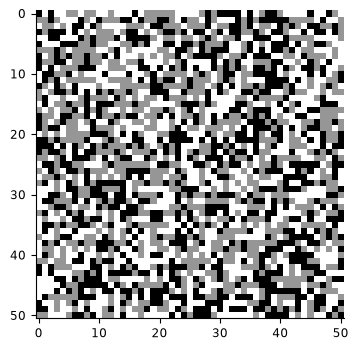

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(12,4))
ax.imshow(stimulus[0], cmap='Greys_r')
stimulus.shape

There are 73 neurons recorded together in V1. To fit the GLM faster, we will focus on one neuron.

In [8]:
print(units)
# this returns TsGroup with one neuron only
spikes = units[[34]]

  Index      rate  location      group
-------  --------  ----------  -------
      1   0.34316  v1                0
     11   0.726    v1                0
     19   0.57753  v1                0
     20   5.96505  v1                0
     23   2.86105  v1                0
     26   3.67212  v1                0
     30   1.47817  v1                0
     33   1.01763  v1                0
     34   8.5582   v1                0
     36   0.45973  v1                0
     38   0.25318  v1                0
     40  21.8111   v1                0
     41   2.12646  v1                0
     50   0.29449  v1                0
     54  12.0761   v1                0
     56   1.09534  v1                0
     60   1.47368  v1                0
     64   0.00164  v1                0
     69   9.08541  v1                0
     72  13.8672   v1                0
     75   1.08389  v1                0
     76   0.97141  v1                0
     81   0.89778  v1                0
     82   1.36529  v1    

How could we predict neuron's response to white noise stimulus?

- we could fit the instantaneous spatial response. that is, just predict
  neuron's response to a given frame of white noise. this will give an x by y
  filter. implicitly assumes that there's no temporal info: only matters what
  we've just seen

- could fit spatiotemporal filter. instead of an x by y that we use
  independently on each frame, fit (x, y, t) over, say 100 msecs. and then
  fit each of these independently (like in head direction example)

- that's a lot of parameters! can simplify by assuming that the response is
  separable: fit a single (x, y) filter and then modulate it over time. this
  wouldn't catch e.g., direction-selectivity because it assumes that phase
  preference is constant over time

- could make use of our knowledge of V1 and try to fit a more complex
  functional form, e.g., a Gabor.

That last one is very non-linear and thus non-convex. we'll do the third one.

in this example, we'll fit the spatial filter outside of the GLM framework,
using spike-triggered average, and then we'll use the GLM to fit the temporal
timecourse.

## Spike-triggered average

Spike-triggered average says: every time our neuron spikes, we store the
stimulus that was on the screen. for the whole recording, we'll have many of
these, which we then average to get this STA, which is the "optimal stimulus"
/ spatial filter.

In practice, we do not just the stimulus on screen, but in some window of
time around it. (it takes some time for info to travel through the eye/LGN to
V1). Pynapple makes this easy:

In [9]:
sta = nap.compute_event_triggered_average(stimulus, spikes, binsize=0.025,
                                        window=(-0.15, 0.0))

sta is a [`TsdTensor`](https://pynapple.org/generated/pynapple.TsdTensor.html), which gives us the 2d receptive field at each of the
time points.

In [10]:
sta

Time (s)
----------  -------------------------------------
-0.15       [[[0.009473 ... 0.008994] ...] ...]
-0.125      [[[0.011004 ... 0.001244] ...] ...]
-0.1        [[[-0.003397 ...  0.004449] ...] ...]
-0.075      [[[-0.004497 ...  0.005167] ...] ...]
-0.05       [[[ 0.008851 ... -0.00555 ] ...] ...]
-0.025      [[[-0.001148 ...  0.009808] ...] ...]
0           [[[0.000765 ... 0.001818] ...] ...]
dtype: float64, shape: (7, 1, 51, 51)

We index into this in a 2d manner: row, column (here we only have 1 column).

In [11]:
sta[1, 0]

array([[ 0.01100373, -0.00052627,  0.00186585, ..., -0.00459286,
        -0.01066884,  0.0012439 ],
       [ 0.00138743,  0.00999904, -0.00478423, ..., -0.00019137,
        -0.00162664,  0.01636207],
       [ 0.0065544 ,  0.00200938, -0.01114726, ..., -0.0046407 ,
        -0.0083724 ,  0.00516697],
       ...,
       [ 0.0003349 ,  0.00291838, -0.00688929, ..., -0.00755909,
        -0.00956846, -0.01789302],
       [-0.01908908,  0.00301407,  0.00478423, ..., -0.00066979,
        -0.00483207,  0.00138743],
       [-0.00172232, -0.00794182, -0.00492776, ...,  0.00315759,
         0.00990336, -0.0012439 ]], shape=(51, 51))

we can easily plot this

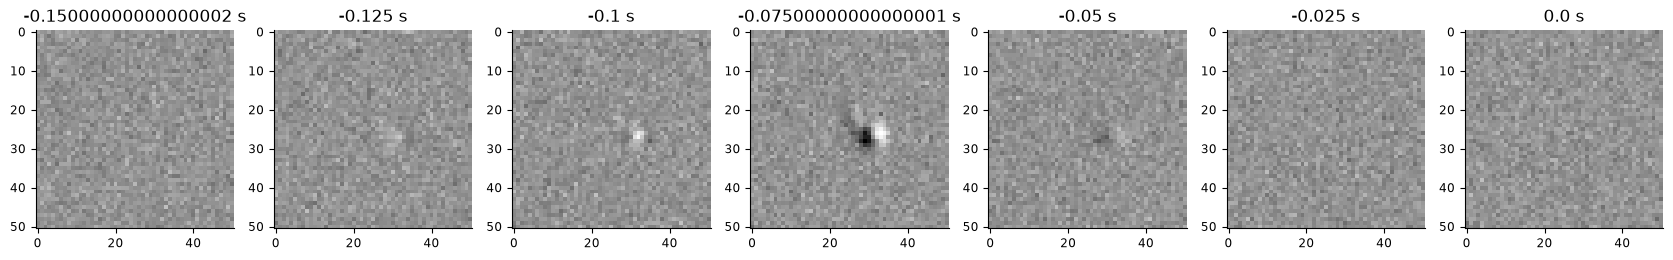

In [12]:
fig, axes = plt.subplots(1, len(sta), figsize=(3*len(sta),3))
for i, t in enumerate(sta.t):
    axes[i].imshow(sta[i,0], vmin = np.min(sta), vmax = np.max(sta),
                   cmap='Greys_r')
    axes[i].set_title(str(t)+" s")

that looks pretty reasonable for a V1 simple cell: localized in space,
orientation, and spatial frequency. that is, looks Gabor-ish

To convert this to the spatial filter we'll use for the GLM, let's take the
average across the bins that look informative: -.125 to -.05

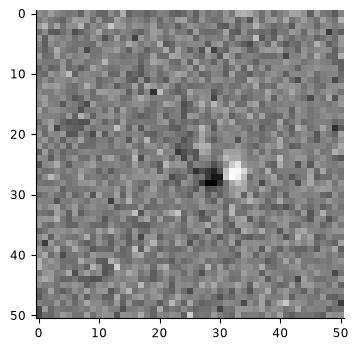

In [13]:
# mkdocs_gallery_thumbnail_number = 3
receptive_field = np.mean(sta.get(-0.125, -0.05), axis=0)[0]

fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.imshow(receptive_field, cmap='Greys_r')

In [14]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/tutorials"
# if local store in assets
else:
   path = Path("../_build/html/_static/thumbnails/tutorials")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_04_v1_cells.svg")

This receptive field gives us the spatial part of the linear response: it
gives a map of weights that we use for a weighted sum on an image. There are
multiple ways of performing this operation:

In [15]:
# element-wise multiplication and sum
print((receptive_field * stimulus[0]).sum())
# dot product of flattened versions
print(np.dot(receptive_field.flatten(), stimulus[0].flatten()))

-0.1176203234140274
-0.11762032341402756


When performing this operation on multiple stimuli, things become slightly
more complicated. For loops on the above methods would work, but would be
slow. Reshaping and using the dot product is one common method, as are
methods like `np.tensordot`.

We'll use einsum to do this, which is a convenient way of representing many
different matrix operations:

In [16]:
filtered_stimulus = np.einsum('t h w, h w -> t', stimulus, receptive_field)

This notation says: take these arrays with dimensions `(t,h,w)` and `(h,w)`
and multiply and sum to get an array of shape `(t,)`. This performs the same
operations as above.

And this remains a pynapple object, so we can easily visualize it!

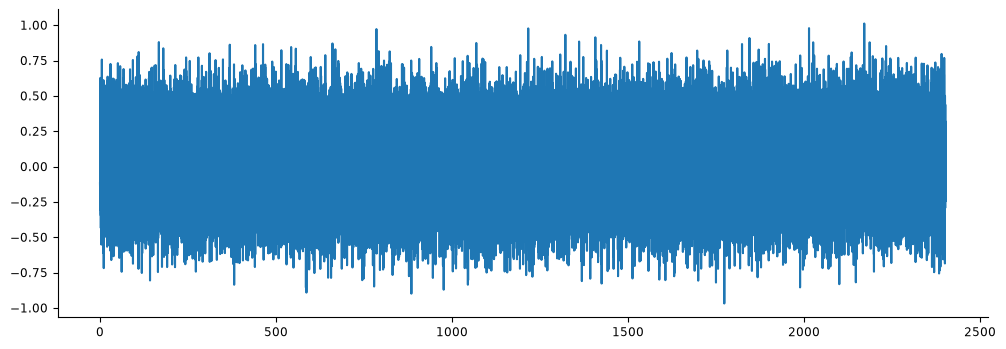

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(12,4))
ax.plot(filtered_stimulus)

But what is this? It's how much each frame in the video should drive our
neuron, based on the receptive field we fit using the spike-triggered
average.

This, then, is the spatial component of our input, as described above.

## Preparing data for NeMoS

We'll now use the GLM to fit the temporal component. To do that, let's get
this and our spike counts into the proper format for NeMoS:

In [18]:
# grab spikes from when we were showing our stimulus, and bin at 1 msec
# resolution
bin_size = .001
counts = spikes[34].restrict(filtered_stimulus.time_support).count(bin_size)

print(counts.rate)
print(filtered_stimulus.rate)

1000.0001425044871
39.9731573425015


Hold on, our stimulus is at a much lower rate than what we want for our rates
-- in previous tutorials, our input has been at a higher rate than our spikes,
and so we used `bin_average` to down-sample to the appropriate rate. When the
input is at a lower rate, we need to think a little more carefully about how
to up-sample.

In [19]:
print(counts[:5])
print(filtered_stimulus[:5])

Time (s)
----------  --
0.0005       0
0.0015       0
0.0025       0
0.0035       0
0.0045       0
dtype: int64, shape: (5,)
Time (s)
----------  ----------
0           -0.11762
0.025017     0.224512
0.0500341    0.0305712
0.0750511    0.297902
0.100068    -0.0934241
dtype: float64, shape: (5,)


What was the visual input to the neuron at time 0.005? It was the same input
as time 0. At time 0.0015? Same thing, up until we pass time 0.025017. Thus,
we want to "fill forward" the values of our input, and we have pynapple
convenience function to do so:

In [20]:
filtered_stimulus = counts.value_from(filtered_stimulus, mode="before")
filtered_stimulus

Time (s)
---------------------  ----------
0.0005                 -0.11762
0.0015                 -0.11762
0.0025                 -0.11762
0.0035                 -0.11762
0.0045000000000000005  -0.11762
0.0055                 -0.11762
0.006500000000000001   -0.11762
...
2401.6305              -0.0683786
2401.6315              -0.0683786
2401.6325              -0.0683786
2401.6335              -0.0683786
2401.6345              -0.0683786
2401.6355000000003     -0.0683786
2401.6365              -0.0683786
dtype: float64, shape: (2401637,)

We can see that the time points are now aligned, and we've filled forward the
values the way we'd like.

Now, similar to the [head direction tutorial](plot_02_head_direction), we'll
use the log-stretched raised cosine basis to create the predictor for our
GLM:

In [21]:
window_size = 100
basis = nmo.basis.RaisedCosineLogConv(8, window_size=window_size)

convolved_input = basis.compute_features(filtered_stimulus)

/home/jenkins/agent/workspace/CCN_nemos_PR-616/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


convolved_input has shape (n_time_pts, n_features * n_basis_funcs), because
n_features is the singleton dimension from filtered_stimulus.

## Fitting the GLM

Now we're ready to fit the model! Let's do it, same as before:

In [22]:
model = nmo.glm.GLM()
model.fit(convolved_input, counts)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7f23083ad760>
,regularizer,UnRegularized()
,solver_name,'LBFGS'
,solver_kwargs,{}
,regularizer_strength,None
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](8,)",Array([-0.383...dtype=float64)
dof_resid_,"ArrayImpl[float64](1,)",Array([240163...dtype=float64)


We have our coefficients for each of our 8 basis functions, let's combine
them to get the temporal time course of our input:

Text(0, 0.5, 'amplitude')

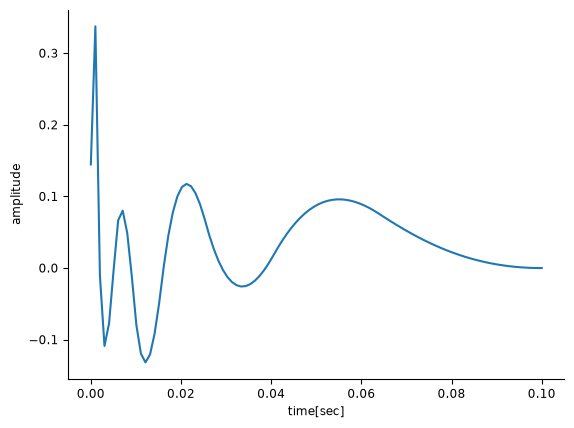

In [23]:
time, basis_kernels = basis.evaluate_on_grid(window_size)
time *= bin_size * window_size
temp_weights = np.einsum('b, t b -> t', model.coef_, basis_kernels)
plt.plot(time, temp_weights)
plt.xlabel("time[sec]")
plt.ylabel("amplitude")

When taken together, the results of the GLM and the spike-triggered average
give us the linear component of our LNP model: the separable spatio-temporal
filter.